In [27]:
# ============================================================
# Core utilities
# ============================================================

import os
import glob
from pathlib import Path

# ============================================================
# Numerical computing
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# MATLAB file handling
# ============================================================

from scipy.io import loadmat

# ============================================================
# Signal processing
# ============================================================

from scipy.signal import spectrogram
from scipy.fft import fft, fftfreq

# ============================================================
# Visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Utilities
# ============================================================

from tqdm import tqdm

# ============================================================
# Plot styling
# ============================================================

sns.set_style("darkgrid")

plt.rcParams["figure.figsize"] = (15, 5)
plt.rcParams["font.size"] = 12

# ============================================================
# Ignore warnings
# ============================================================

import warnings
warnings.filterwarnings("ignore")

DATASET_PATH = r"E:\CHANDRASEKHAR_DRONE_DATA\MPACT_DroneRC_RF_Dataset\MPACT_DroneRC_RF_Dataset"

print("utilities ready")

utilities ready


Number of controller folders: 17

Controller Classes:

DJI_Inspire1Pro
DJI_Matrice100
DJI_Matrice600_1
DJI_Matrice600_2
DJI_Phantom3
DJI_Phantom4Pro_1
DJI_Phantom4Pro_2
FlySky_FST6
Futaba_T8FG
Graupner_MC32
HobbyKing_HKT6A
JetiDuplex_DC16
Spektrum_DX5e
Spektrum_DX6e
Spektrum_DX6i
Spektrum_JRX9303
Turnigy_9X


,Controller,NumSignals
9,Graupner_MC32,1191
8,Futaba_T8FG,1149
2,DJI_Matrice600_1,1101
11,JetiDuplex_DC16,1049
16,Turnigy_9X,1048
3,DJI_Matrice600_2,1014
5,DJI_Phantom4Pro_1,1000
6,DJI_Phantom4Pro_2,1000
7,FlySky_FST6,1000
4,DJI_Phantom3,1000


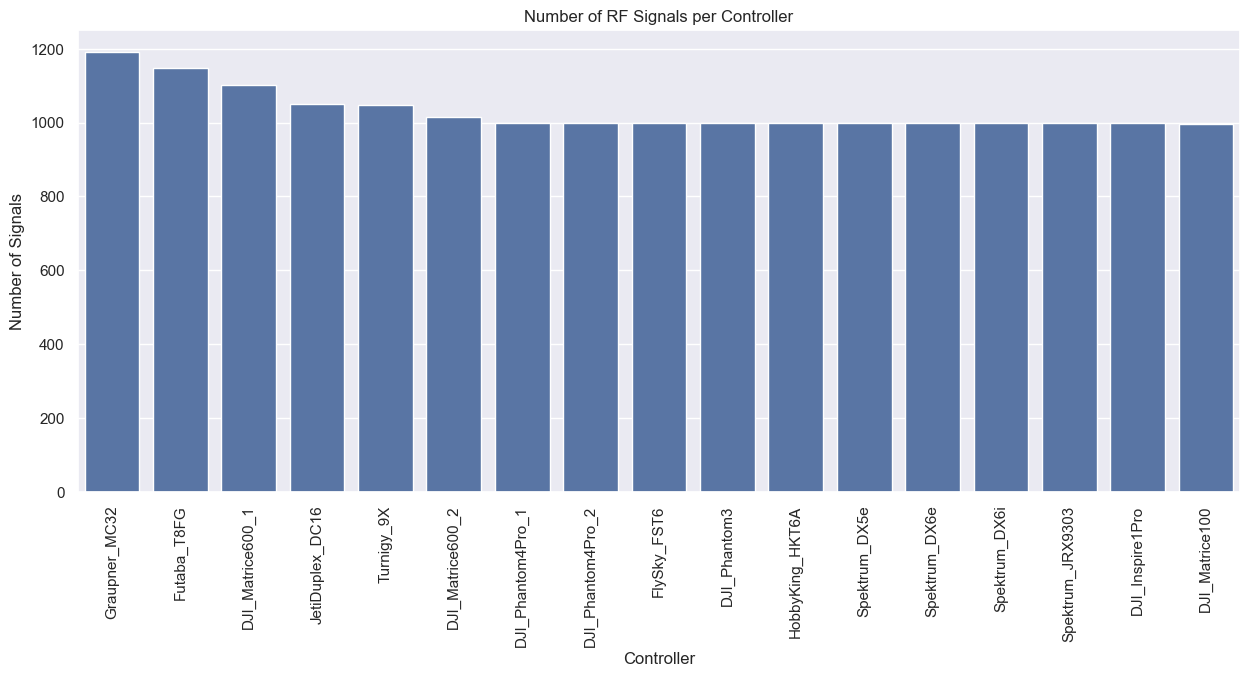

In [28]:
# ============================================================
# Explore dataset structure
# ============================================================

controller_folders = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print(f"Number of controller folders: {len(controller_folders)}")
print("\nController Classes:\n")

for folder in controller_folders:
    print(folder)

# ============================================================
# Count .mat files per controller
# ============================================================

class_counts = {}

for folder in controller_folders:

    folder_path = os.path.join(DATASET_PATH, folder)

    mat_files = glob.glob(os.path.join(folder_path, "*.mat"))

    class_counts[folder] = len(mat_files)

# ============================================================
# Create dataframe
# ============================================================

df_classes = pd.DataFrame({
    "Controller": class_counts.keys(),
    "NumSignals": class_counts.values()
})

df_classes = df_classes.sort_values(
    by="NumSignals",
    ascending=False
)

display(df_classes)

# ============================================================
# Visualize class distribution
# ============================================================

plt.figure(figsize=(15,6))

sns.barplot(
    data=df_classes,
    x="Controller",
    y="NumSignals"
)

plt.xticks(rotation=90)

plt.title("Number of RF Signals per Controller")
plt.xlabel("Controller")
plt.ylabel("Number of Signals")

plt.show()

In [29]:
# ============================================================
# Select and inspect one sample RF file
# ============================================================

# Pick first controller folder
sample_class = controller_folders[0]

# Pick first .mat file from that folder
sample_file = glob.glob(
    os.path.join(DATASET_PATH, sample_class, "*.mat")
)[0]

print("Sample class:")
print(sample_class)

print("\nSample file:")
print(sample_file)

# ============================================================
# Load MATLAB file
# ============================================================

mat_data = loadmat(sample_file)

print("\nMATLAB keys:")
print(mat_data.keys())

# ============================================================
# Access structured RF data
# ============================================================

data_struct = mat_data['data']

print("\nAvailable RF metadata fields:")
print(data_struct.dtype.names)

# ============================================================
# Extract metadata
# ============================================================

num_samples = data_struct['NumPoints'][0,0][0,0]

xinc = data_struct['XInc'][0,0][0,0]
yinc = data_struct['YInc'][0,0][0,0]
yorg = data_struct['YOrg'][0,0][0,0]

Fs = 1 / xinc

# ============================================================
# Extract raw ADC waveform
# ============================================================

signal_adc = data_struct['Data'][0,0].squeeze()

# ============================================================
# Convert ADC counts -> voltage
# ============================================================

signal = yorg + yinc * signal_adc

# ============================================================
# Print metadata summary
# ============================================================

print("\n========== RF SIGNAL METADATA ==========")

print(f"Number of Samples      : {num_samples:,}")
print(f"Sampling Frequency     : {Fs/1e9:.2f} GHz")
print(f"Signal Duration        : {num_samples/Fs * 1e6:.2f} microseconds")

print(f"\nSignal dtype           : {signal.dtype}")
print(f"Signal shape           : {signal.shape}")

print(f"\nVoltage Min            : {signal.min():.6f} V")
print(f"Voltage Max            : {signal.max():.6f} V")
print(f"Voltage Mean           : {signal.mean():.6f} V")
print(f"Voltage Std            : {signal.std():.6f} V")

print(f"\nComplex IQ Signal?     : {np.iscomplexobj(signal)}")

print("\n========================================")

Sample class:
DJI_Inspire1Pro

Sample file:
E:\CHANDRASEKHAR_DRONE_DATA\MPACT_DroneRC_RF_Dataset\MPACT_DroneRC_RF_Dataset\DJI_Inspire1Pro\DJI_Inspire1Pro_0001.mat

MATLAB keys:
dict_keys(['__header__', '__version__', '__globals__', 'data'])

Available RF metadata fields:
('NumPoints', 'NumSegments', 'WaveformType', 'XDispOrigin', 'XDispRange', 'XInc', 'XOrg', 'XUnits', 'YDispOrigin', 'YDispRange', 'YInc', 'YOrg', 'YUnits', 'Data')

========== RF SIGNAL METADATA ==========
Number of Samples      : 5,000,000
Sampling Frequency     : 20.00 GHz
Signal Duration        : 250.00 microseconds

Signal dtype           : float64
Signal shape           : (5000000,)

Voltage Min            : -0.136702 V
Voltage Max            : 0.135569 V
Voltage Mean           : -0.000118 V
Voltage Std            : 0.033786 V

Complex IQ Signal?     : False



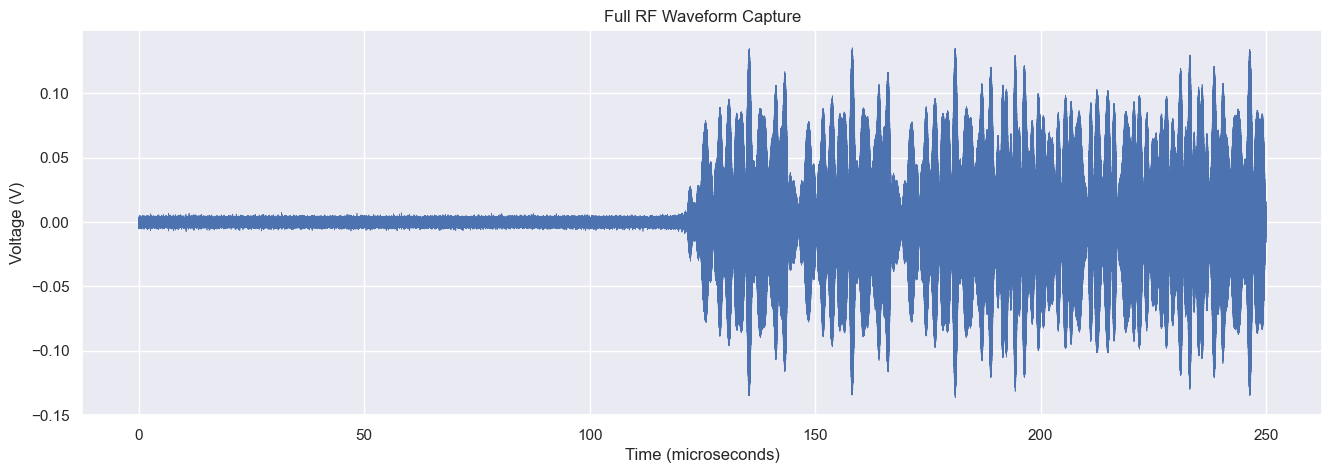

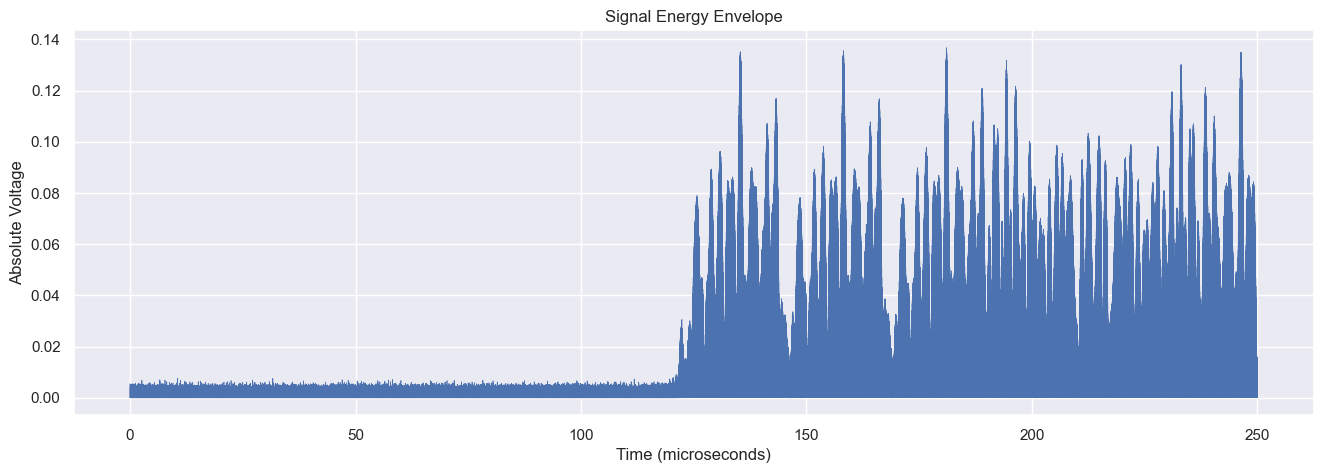

In [30]:
# ============================================================
# Visualize full RF waveform
# ============================================================

# Create time axis in microseconds
time_us = np.arange(len(signal)) / Fs * 1e6

# ============================================================
# Plot full waveform
# ============================================================

plt.figure(figsize=(16,5))

plt.plot(time_us, signal, linewidth=0.5)

plt.title("Full RF Waveform Capture")
plt.xlabel("Time (microseconds)")
plt.ylabel("Voltage (V)")

plt.show()

# ============================================================
# Basic signal energy visualization
# ============================================================

energy = np.abs(signal)

plt.figure(figsize=(16,5))

plt.plot(time_us, energy, linewidth=0.5)

plt.title("Signal Energy Envelope")
plt.xlabel("Time (microseconds)")
plt.ylabel("Absolute Voltage")

plt.show()

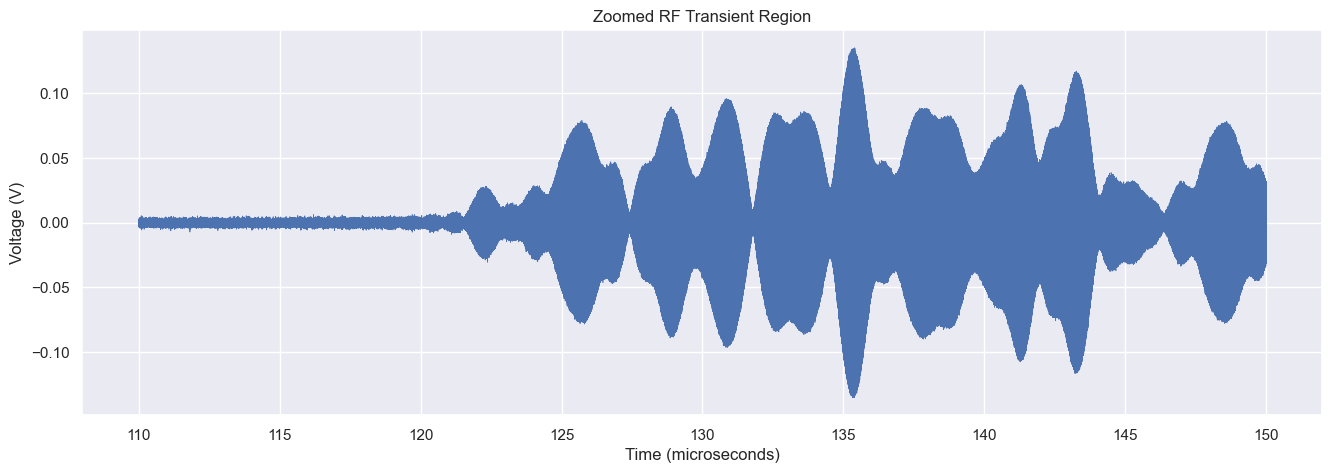

In [31]:
# ============================================================
# Zoom into transient onset region
# ============================================================

# Approximate transient region from visual inspection
zoom_start_us = 110
zoom_end_us = 150

# Convert microseconds -> sample indices
start_idx = int((zoom_start_us * 1e-6) * Fs)
end_idx = int((zoom_end_us * 1e-6) * Fs)

# Extract zoomed region
zoom_signal = signal[start_idx:end_idx]

zoom_time_us = np.arange(len(zoom_signal)) / Fs * 1e6 + zoom_start_us

# ============================================================
# Plot transient region
# ============================================================

plt.figure(figsize=(16,5))

plt.plot(zoom_time_us, zoom_signal, linewidth=0.5)

plt.title("Zoomed RF Transient Region")
plt.xlabel("Time (microseconds)")
plt.ylabel("Voltage (V)")

plt.show()

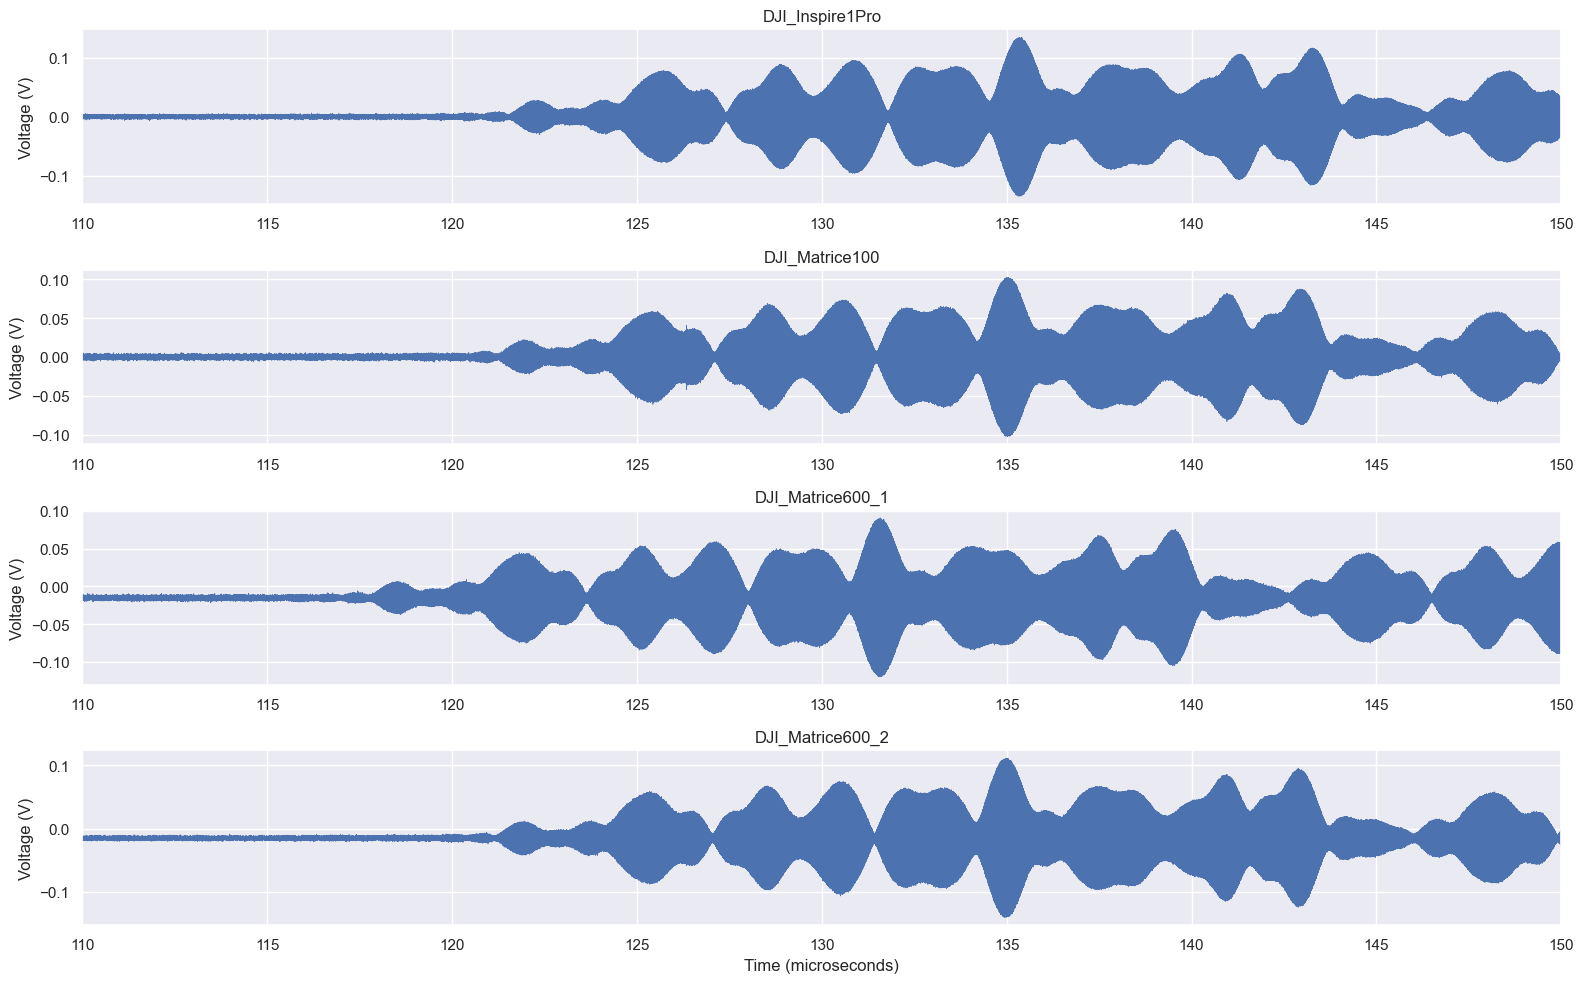

In [32]:
# ============================================================
# Compare transient regions across multiple controllers
# ============================================================

comparison_signals = {}

# Number of controllers to compare
NUM_CONTROLLERS = 4

selected_controllers = controller_folders[:NUM_CONTROLLERS]

# ============================================================
# Load one signal from each controller
# ============================================================

for controller in selected_controllers:

    file_path = glob.glob(
        os.path.join(DATASET_PATH, controller, "*.mat")
    )[0]

    # Load MATLAB file
    mat_data = loadmat(file_path)

    data_struct = mat_data['data']

    # Extract scaling metadata
    yinc = data_struct['YInc'][0,0][0,0]
    yorg = data_struct['YOrg'][0,0][0,0]

    # Extract waveform
    signal_adc = data_struct['Data'][0,0].squeeze()

    # Convert to voltage
    signal = yorg + yinc * signal_adc

    # Store
    comparison_signals[controller] = signal

# ============================================================
# Plot transient regions
# ============================================================

plt.figure(figsize=(16,10))

for idx, (controller, signal) in enumerate(comparison_signals.items(), start=1):

    # Approximate transient region
    zoom_start_us = 110
    zoom_end_us = 150

    start_idx = int((zoom_start_us * 1e-6) * Fs)
    end_idx = int((zoom_end_us * 1e-6) * Fs)

    transient = signal[start_idx:end_idx]

    time_axis = (
        np.arange(len(transient)) / Fs * 1e6
        + zoom_start_us
    )

    plt.subplot(NUM_CONTROLLERS, 1, idx)

    plt.plot(time_axis, transient, linewidth=0.5)

    plt.title(controller)

    plt.xlim(110, 150)

    plt.ylabel("Voltage (V)")

plt.xlabel("Time (microseconds)")

plt.tight_layout()

plt.show()

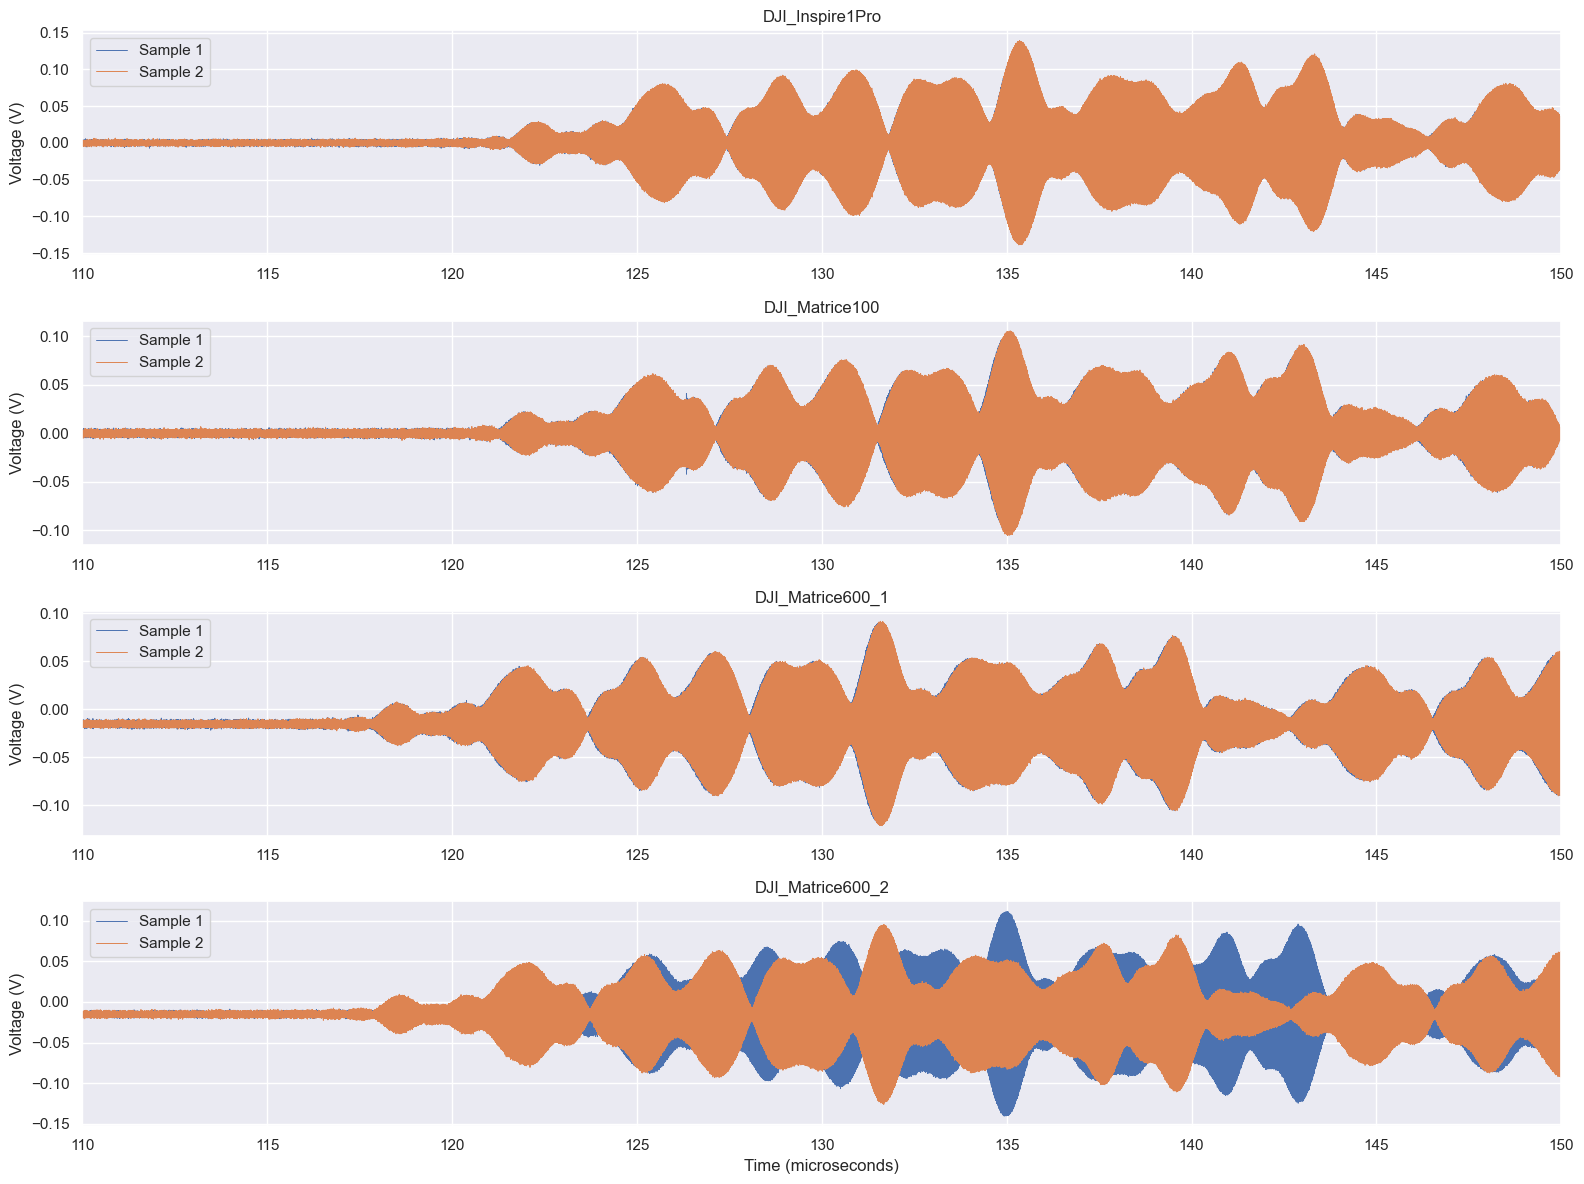

In [39]:
# ============================================================
# Compare multiple waveform captures per controller
# ============================================================

NUM_CONTROLLERS = 4

selected_controllers = controller_folders[:NUM_CONTROLLERS]

plt.figure(figsize=(16,12))

plot_idx = 1

for controller in selected_controllers:

    # ========================================================
    # Load two waveform samples
    # ========================================================

    files = sorted(
        glob.glob(os.path.join(DATASET_PATH, controller, "*.mat"))
    )[:2]

    controller_signals = []

    for file_path in files:

        mat_data = loadmat(file_path)

        data_struct = mat_data['data']

        yinc = data_struct['YInc'][0,0][0,0]
        yorg = data_struct['YOrg'][0,0][0,0]

        signal_adc = data_struct['Data'][0,0].squeeze()

        signal = yorg + yinc * signal_adc

        controller_signals.append(signal)

    # ========================================================
    # Plot the two captures
    # ========================================================

    plt.subplot(NUM_CONTROLLERS, 1, plot_idx)

    for idx, signal in enumerate(controller_signals):

        # Approx transient region
        zoom_start_us = 110
        zoom_end_us = 150

        start_idx = int((zoom_start_us * 1e-6) * Fs)
        end_idx = int((zoom_end_us * 1e-6) * Fs)

        transient = signal[start_idx:end_idx]

        time_axis = (
            np.arange(len(transient)) / Fs * 1e6
            + zoom_start_us
        )

        plt.plot(
            time_axis,
            transient,
            linewidth=0.7,
            label=f"Sample {idx+1}"
        )

    plt.title(controller)

    plt.ylabel("Voltage (V)")

    plt.xlim(110, 150)

    plt.legend()

    plot_idx += 1

plt.xlabel("Time (microseconds)")

plt.tight_layout()

plt.show()

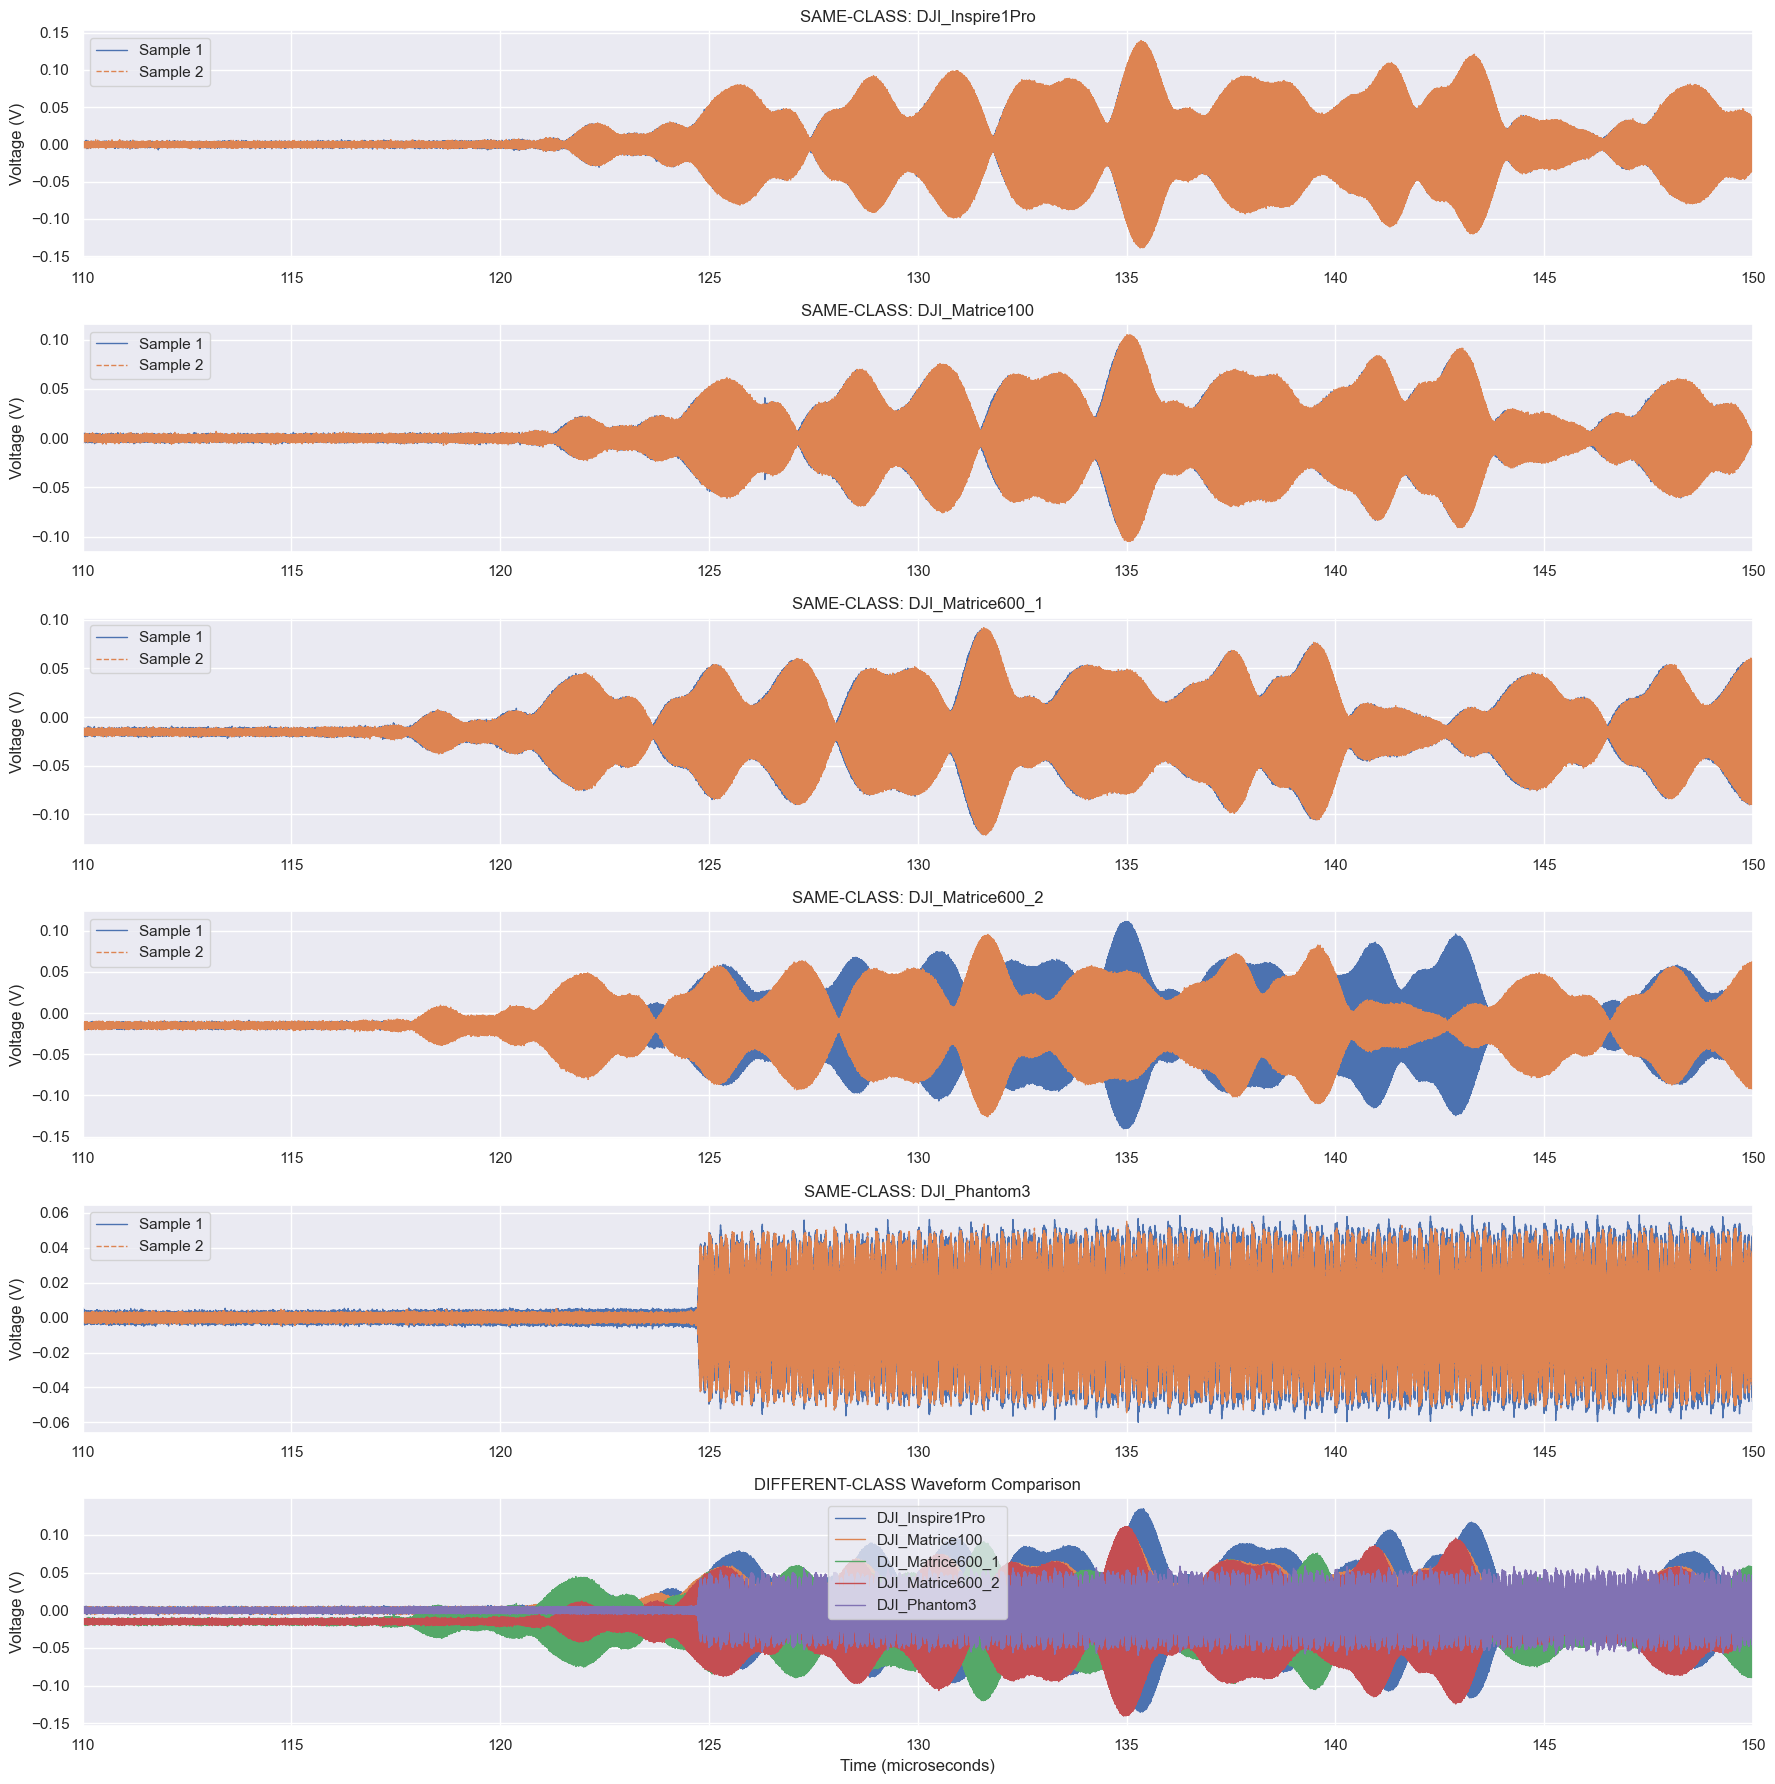

In [42]:
# ============================================================
# SAME-class vs DIFFERENT-class comparison
# ============================================================

NUM_CONTROLLERS = 5

selected_controllers = controller_folders[:NUM_CONTROLLERS]

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def load_signal(file_path):

    mat_data = loadmat(file_path)

    data_struct = mat_data['data']

    yinc = data_struct['YInc'][0,0][0,0]
    yorg = data_struct['YOrg'][0,0][0,0]

    signal_adc = data_struct['Data'][0,0].squeeze()

    signal = yorg + yinc * signal_adc

    return signal

# ------------------------------------------------------------
# Transient region
# ------------------------------------------------------------

zoom_start_us = 110
zoom_end_us = 150

start_idx = int((zoom_start_us * 1e-6) * Fs)
end_idx = int((zoom_end_us * 1e-6) * Fs)

# ============================================================
# SAME-CLASS CONSISTENCY
# ============================================================

fig, axes = plt.subplots(
    NUM_CONTROLLERS + 1,
    1,
    figsize=(18, 3 * (NUM_CONTROLLERS + 1))
)

# ------------------------------------------------------------
# SAME-controller comparisons
# ------------------------------------------------------------

for idx, controller in enumerate(selected_controllers):

    files = sorted(
        glob.glob(os.path.join(DATASET_PATH, controller, "*.mat"))
    )[:2]

    signal_1 = load_signal(files[0])[start_idx:end_idx]
    signal_2 = load_signal(files[1])[start_idx:end_idx]

    time_axis = (
        np.arange(len(signal_1)) / Fs * 1e6
        + zoom_start_us
    )

    ax = axes[idx]

    ax.plot(
        time_axis,
        signal_1,
        linewidth=1,
        label="Sample 1"
    )

    ax.plot(
        time_axis,
        signal_2,
        linewidth=1,
        linestyle='--',
        label="Sample 2"
    )

    ax.set_title(f"SAME-CLASS: {controller}")

    ax.set_xlim(110,150)

    ax.set_ylabel("Voltage (V)")

    ax.legend()

# ============================================================
# DIFFERENT-CLASS COMPARISON
# ============================================================

ax = axes[-1]

for controller in selected_controllers:

    file_path = sorted(
        glob.glob(os.path.join(DATASET_PATH, controller, "*.mat"))
    )[0]

    signal = load_signal(file_path)[start_idx:end_idx]

    time_axis = (
        np.arange(len(signal)) / Fs * 1e6
        + zoom_start_us
    )

    ax.plot(
        time_axis,
        signal,
        linewidth=1,
        label=controller
    )

ax.set_title("DIFFERENT-CLASS Waveform Comparison")

ax.set_xlim(110,150)

ax.set_xlabel("Time (microseconds)")
ax.set_ylabel("Voltage (V)")

ax.legend()

plt.tight_layout()

plt.show()

In [ ]:
#Understanding controller also separate through transient morphoogy and not just amplitude changes


Checking: DJI_Inspire1Pro
Transient start: 2,436,814


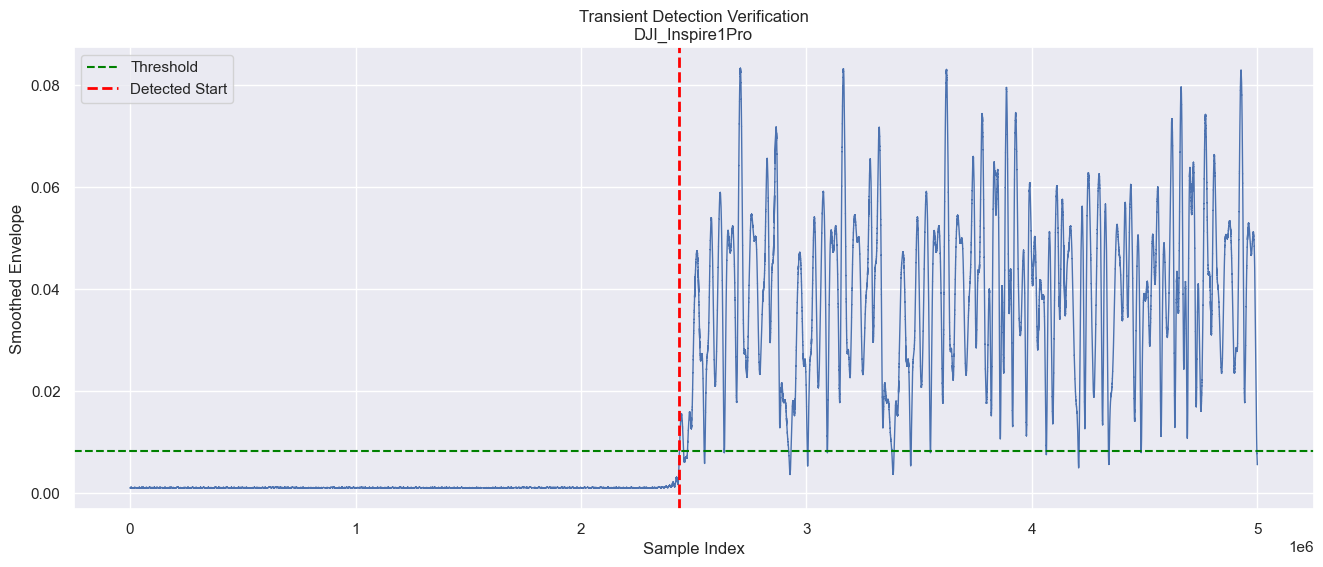

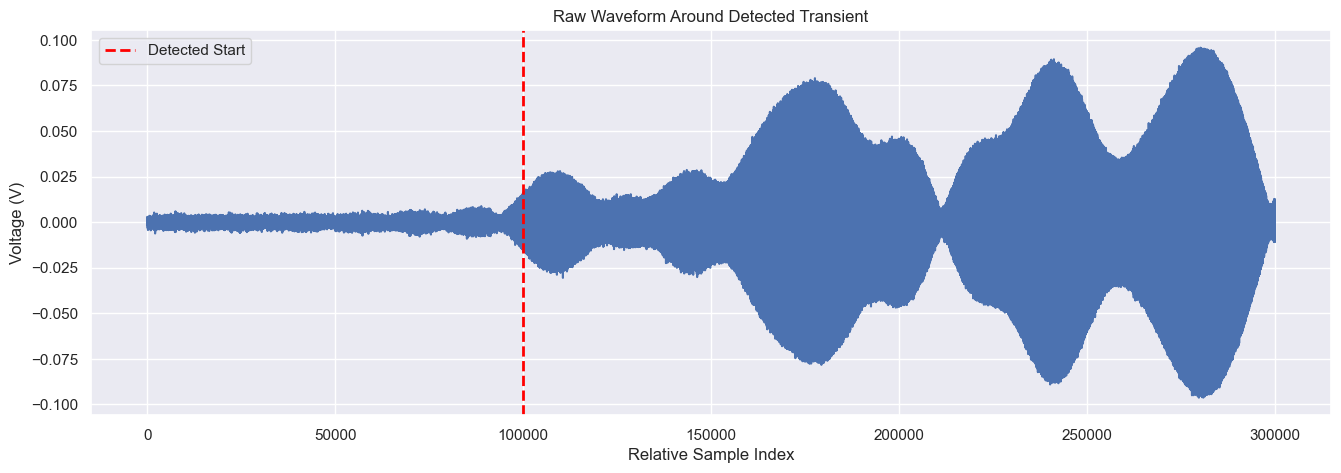

Transient start: 2,436,994
Transient start: 2,436,173
Transient start: 2,436,375
Transient start: 2,437,309

Checking: DJI_Matrice100
Transient start: 2,430,730
Transient start: 2,431,539
Transient start: 2,432,613
Transient start: 2,433,258
Transient start: 0

Checking: DJI_Matrice600_1
Transient start: 0
Transient start: 0
Transient start: 0
Transient start: 0
Transient start: 0

Checking: DJI_Matrice600_2
Transient start: 0
Transient start: 0
Transient start: 0
Transient start: 0
Transient start: 0

Checking: DJI_Phantom3
Transient start: 2,492,844
Transient start: 2,493,116
Transient start: 2,493,006
Transient start: 2,492,968
Transient start: 2,492,996

Min transient start : 0
Max transient start : 2,493,116
Mean transient start: 1,375,069


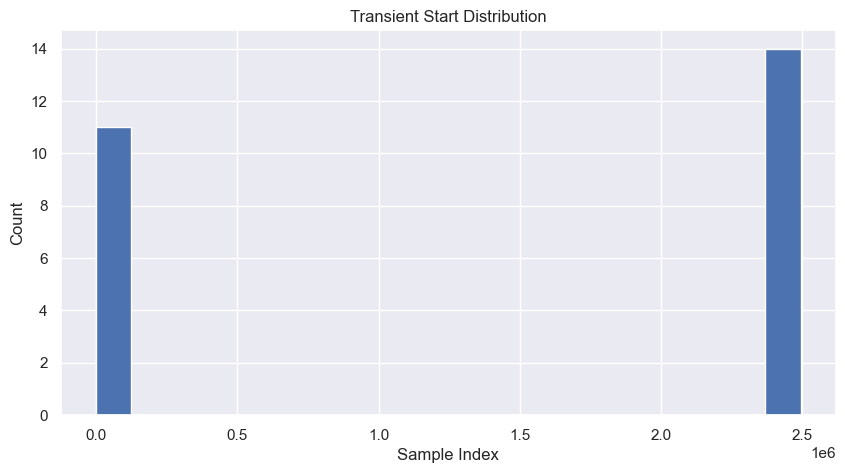

In [51]:
# ============================================================
# Proper transient location analysis with visual verification
# ============================================================

from scipy.ndimage import uniform_filter1d

sample_results = []

NUM_CONTROLLERS_TO_CHECK = 5
FILES_PER_CONTROLLER = 5

selected_controllers = controller_folders[:NUM_CONTROLLERS_TO_CHECK]

# ============================================================
# Helper
# ============================================================

def load_signal(file_path):

    mat_data = loadmat(file_path)

    data_struct = mat_data['data']

    yinc = data_struct['YInc'][0,0][0,0]
    yorg = data_struct['YOrg'][0,0][0,0]

    signal_adc = data_struct['Data'][0,0].squeeze()

    signal = yorg + yinc * signal_adc

    return signal.astype(np.float32)

# ============================================================
# Improved transient detector
# ============================================================

def detect_transient_full(signal):

    envelope = np.abs(signal)

    smooth = uniform_filter1d(
        envelope,
        size=5000
    )

    threshold = 0.10 * np.max(smooth)

    indices = np.where(smooth > threshold)[0]

    if len(indices) == 0:
        return None, smooth, threshold

    # --------------------------------------------------------
    # Require sustained energy rise
    # --------------------------------------------------------

    MIN_CONSECUTIVE = 10000

    for idx in indices:

        end_idx = idx + MIN_CONSECUTIVE

        if end_idx >= len(smooth):
            break

        if np.all(smooth[idx:end_idx] > threshold):

            return idx, smooth, threshold

    return None, smooth, threshold

# ============================================================
# Analyze transient locations
# ============================================================

first_valid_plot_done = False

for controller in selected_controllers:

    print(f"\nChecking: {controller}")

    files = sorted(
        glob.glob(
            os.path.join(DATASET_PATH, controller, "*.mat")
        )
    )[:FILES_PER_CONTROLLER]

    for file_path in files:

        signal = load_signal(file_path)

        start_idx, smooth, threshold = detect_transient_full(signal)

        if start_idx is not None:

            sample_results.append(start_idx)

            print(f"Transient start: {start_idx:,}")

            # =================================================
            # Visual verification
            # =================================================

            if not first_valid_plot_done:

                plt.figure(figsize=(16,6))

                plt.plot(
                    smooth,
                    linewidth=1
                )

                plt.axhline(
                    threshold,
                    color='green',
                    linestyle='--',
                    label='Threshold'
                )

                plt.axvline(
                    start_idx,
                    color='red',
                    linestyle='--',
                    linewidth=2,
                    label='Detected Start'
                )

                plt.title(
                    f"Transient Detection Verification\n{controller}"
                )

                plt.xlabel("Sample Index")

                plt.ylabel("Smoothed Envelope")

                plt.legend()

                plt.show()

                # --------------------------------------------
                # Raw waveform around transient
                # --------------------------------------------

                zoom_before = 100_000
                zoom_after  = 200_000

                s = max(start_idx - zoom_before, 0)
                e = min(start_idx + zoom_after, len(signal))

                plt.figure(figsize=(16,5))

                plt.plot(signal[s:e])

                plt.axvline(
                    zoom_before,
                    color='red',
                    linestyle='--',
                    linewidth=2,
                    label='Detected Start'
                )

                plt.title(
                    "Raw Waveform Around Detected Transient"
                )

                plt.xlabel("Relative Sample Index")

                plt.ylabel("Voltage (V)")

                plt.legend()

                plt.show()

                first_valid_plot_done = True

# ============================================================
# Summary statistics
# ============================================================

sample_results = np.array(sample_results)

print("\n===================================")

print(f"Min transient start : {sample_results.min():,}")

print(f"Max transient start : {sample_results.max():,}")

print(f"Mean transient start: {sample_results.mean():,.0f}")

print("===================================")

# ============================================================
# Histogram
# ============================================================

plt.figure(figsize=(10,5))

plt.hist(
    sample_results,
    bins=20
)

plt.title("Transient Start Distribution")

plt.xlabel("Sample Index")

plt.ylabel("Count")

plt.show()

In [52]:
# ============================================================
# Create transient-aligned waveform dataset
# ============================================================

# Goal:
# 1. Fast transient detection
# 2. Extract aligned transient window
# 3. Normalize waveform
# 4. Build tensors + labels
# 5. Save processed dataset to disk
# 6. Save transient start metadata
# ============================================================

import os
import glob
import json
import numpy as np

from tqdm import tqdm
from scipy.io import loadmat
from scipy.ndimage import uniform_filter1d

# ============================================================
# Configuration
# ============================================================

WINDOW_SIZE = 200_000          # ~10 microseconds
MAX_FILES_PER_CLASS = 50

SAVE_DIR = r"E:\CHANDRASEKHAR_DRONE_DATA\processed_dataset"

os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Fast transient search region
# Validated empirically via EDA
# ------------------------------------------------------------

SEARCH_START = 2_000_000
SEARCH_END   = 3_000_000

# ------------------------------------------------------------
# Shift backward slightly after detection
# so we capture startup ramp
# ------------------------------------------------------------

BACKTRACK = 50_000

# ------------------------------------------------------------
# Smoothing window
# ------------------------------------------------------------

SMOOTH_WINDOW = 5000

# ------------------------------------------------------------
# Require sustained elevated energy
# prevents false triggering
# ------------------------------------------------------------

MIN_CONSECUTIVE = 10_000

# ============================================================
# Storage
# ============================================================

X = []
y = []

label_map = {}

# Save transient metadata too
transient_metadata = []

# ============================================================
# Helper: load waveform
# ============================================================

def load_signal(file_path):

    mat_data = loadmat(file_path)

    data_struct = mat_data['data']

    yinc = data_struct['YInc'][0,0][0,0]
    yorg = data_struct['YOrg'][0,0][0,0]

    signal_adc = data_struct['Data'][0,0].squeeze()

    signal = yorg + yinc * signal_adc

    return signal.astype(np.float32)

# ============================================================
# Helper: transient detection
# ============================================================

def detect_transient_start(signal):

    # --------------------------------------------------------
    # Search only likely transient region
    # Huge speedup
    # --------------------------------------------------------

    search_region = signal[SEARCH_START:SEARCH_END]

    # --------------------------------------------------------
    # Envelope
    # --------------------------------------------------------

    envelope = np.abs(search_region)

    # --------------------------------------------------------
    # Fast smoothing
    # --------------------------------------------------------

    smooth = uniform_filter1d(
        envelope,
        size=SMOOTH_WINDOW
    )

    # --------------------------------------------------------
    # Relative threshold
    # --------------------------------------------------------

    threshold = 0.10 * np.max(smooth)

    indices = np.where(smooth > threshold)[0]

    if len(indices) == 0:
        return None

    # --------------------------------------------------------
    # Require sustained activity
    # --------------------------------------------------------

    for idx in indices:

        end_idx = idx + MIN_CONSECUTIVE

        if end_idx >= len(smooth):
            break

        if np.all(smooth[idx:end_idx] > threshold):

            start_idx = SEARCH_START + max(
                idx - BACKTRACK,
                0
            )

            return start_idx

    return None

# ============================================================
# Process dataset
# ============================================================

for label_idx, controller in enumerate(controller_folders):

    print(f"\nProcessing: {controller}")

    label_map[label_idx] = controller

    files = sorted(
        glob.glob(
            os.path.join(
                DATASET_PATH,
                controller,
                "*.mat"
            )
        )
    )[:MAX_FILES_PER_CLASS]

    for file_path in tqdm(files):

        try:

            # ------------------------------------------------
            # Load waveform
            # ------------------------------------------------

            signal = load_signal(file_path)

            # ------------------------------------------------
            # Detect transient start
            # ------------------------------------------------

            start_idx = detect_transient_start(signal)

            if start_idx is None:
                continue

            # ------------------------------------------------
            # Extract aligned transient window
            # ------------------------------------------------

            end_idx = start_idx + WINDOW_SIZE

            if end_idx >= len(signal):
                continue

            transient = signal[start_idx:end_idx]

            # ------------------------------------------------
            # Normalize waveform
            # ------------------------------------------------

            transient = transient - np.mean(transient)

            transient = transient / (
                np.std(transient) + 1e-12
            )

            # ------------------------------------------------
            # Store waveform + label
            # ------------------------------------------------

            X.append(
                transient.astype(np.float32)
            )

            y.append(label_idx)

            # ------------------------------------------------
            # Save metadata
            # ------------------------------------------------

            transient_metadata.append({

                "controller": controller,

                "file_path": file_path,

                "start_idx": int(start_idx),

                "end_idx": int(end_idx)

            })

        except Exception as e:

            print("\nError processing:")
            print(file_path)
            print(e)

# ============================================================
# Convert to numpy arrays
# ============================================================

X = np.array(X, dtype=np.float32)

y = np.array(y, dtype=np.int64)

# ============================================================
# Save dataset
# ============================================================

np.save(
    os.path.join(SAVE_DIR, "X.npy"),
    X
)

np.save(
    os.path.join(SAVE_DIR, "y.npy"),
    y
)

# ============================================================
# Save label mapping
# ============================================================

with open(
    os.path.join(SAVE_DIR, "label_map.json"),
    "w"
) as f:

    json.dump(label_map, f, indent=4)

# ============================================================
# Save transient metadata
# ============================================================

with open(
    os.path.join(SAVE_DIR, "transient_metadata.json"),
    "w"
) as f:

    json.dump(transient_metadata, f, indent=4)

# ============================================================
# Summary
# ============================================================

print("\n===================================")

print("Dataset Created Successfully")

print(f"\nX shape: {X.shape}")

print(f"y shape: {y.shape}")

print(f"\nNumber of classes: {len(label_map)}")

print(f"\nSaved to: {SAVE_DIR}")

print("\nClass Mapping:")

for k, v in label_map.items():

    print(f"{k} --> {v}")

print("\nMetadata saved:")
print("transient_metadata.json")

print("===================================")


Processing: DJI_Inspire1Pro


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:04<00:00, 11.15it/s]



Processing: DJI_Matrice100


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:04<00:00, 11.53it/s]



Processing: DJI_Matrice600_1


...


Processing: Spektrum_JRX9303


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:04<00:00, 11.39it/s]



Processing: Turnigy_9X


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:04<00:00, 11.48it/s]



Dataset Created Successfully

X shape: (850, 200000)
y shape: (850,)

Number of classes: 17

Saved to: E:\CHANDRASEKHAR_DRONE_DATA\processed_dataset

Class Mapping:
0 --> DJI_Inspire1Pro
1 --> DJI_Matrice100
2 --> DJI_Matrice600_1
3 --> DJI_Matrice600_2
4 --> DJI_Phantom3
5 --> DJI_Phantom4Pro_1
6 --> DJI_Phantom4Pro_2
7 --> FlySky_FST6
8 --> Futaba_T8FG
9 --> Graupner_MC32
10 --> HobbyKing_HKT6A
11 --> JetiDuplex_DC16
12 --> Spektrum_DX5e
13 --> Spektrum_DX6e
14 --> Spektrum_DX6i
15 --> Spektrum_JRX9303
16 --> Turnigy_9X

Metadata saved:
transient_metadata.json


In [54]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# ============================================================
# Load processed dataset
# ============================================================

X = np.load(
    r"E:\CHANDRASEKHAR_DRONE_DATA\processed_dataset\X.npy"
)

y = np.load(
    r"E:\CHANDRASEKHAR_DRONE_DATA\processed_dataset\y.npy"
)

print("Loaded dataset:")
print("X shape:", X.shape)
print("y shape:", y.shape)

# ============================================================
# Add channel dimension for Conv1D
# ============================================================

# Conv1D expects:
# (batch, sequence_length, channels)

X = X[..., np.newaxis]

print("\nAfter channel expansion:")
print("X shape:", X.shape)

# ============================================================
# Train / Validation / Test Split
# ============================================================

# First:
# 80% train
# 20% temp

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Then:
# split temp into:
# 10% validation
# 10% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Summary
# ============================================================

print("\n===================================")

print("Dataset Split Complete")

print(f"\nTrain Shape: {X_train.shape}")
print(f"Validation Shape: {X_val.shape}")
print(f"Test Shape: {X_test.shape}")

print("\nLabel Shapes:")

print(f"y_train: {y_train.shape}")
print(f"y_val  : {y_val.shape}")
print(f"y_test : {y_test.shape}")

print("===================================")

Loaded dataset:
X shape: (850, 200000)
y shape: (850,)

After channel expansion:
X shape: (850, 200000, 1)

Dataset Split Complete

Train Shape: (680, 200000, 1)
Validation Shape: (85, 200000, 1)
Test Shape: (85, 200000, 1)

Label Shapes:
y_train: (680,)
y_val  : (85,)
y_test : (85,)


In [56]:
# ============================================================
# Improved RF Waveform CNN
# ============================================================

# Key Improvements:
# 1. Larger temporal receptive fields
# 2. Aggressive early downsampling
# 3. More convolutional capacity
# 4. Removed BatchNorm instability
# 5. Lower learning rate
# 6. Better suited for RF transients
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    ReLU,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# ============================================================
# Build Model
# ============================================================

model = Sequential([

    # ========================================================
    # Block 1
    # Large RF receptive field + strong downsampling
    # ========================================================

    Conv1D(
        filters=64,
        kernel_size=31,
        strides=8,
        padding='same',
        input_shape=X_train.shape[1:]
    ),

    ReLU(),

    MaxPooling1D(pool_size=4),

    # ========================================================
    # Block 2
    # ========================================================

    Conv1D(
        filters=128,
        kernel_size=15,
        padding='same'
    ),

    ReLU(),

    MaxPooling1D(pool_size=4),

    # ========================================================
    # Block 3
    # ========================================================

    Conv1D(
        filters=256,
        kernel_size=7,
        padding='same'
    ),

    ReLU(),

    MaxPooling1D(pool_size=2),

    # ========================================================
    # Block 4
    # ========================================================

    Conv1D(
        filters=256,
        kernel_size=5,
        padding='same'
    ),

    ReLU(),

    # ========================================================
    # Global feature aggregation
    # ========================================================

    GlobalAveragePooling1D(),

    # ========================================================
    # Dense classifier
    # ========================================================

    Dense(256, activation='relu'),

    Dropout(0.4),

    Dense(
        len(np.unique(y)),
        activation='softmax'
    )

])

# ============================================================
# Compile
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

# ============================================================
# Model Summary
# ============================================================

model.summary()

# ============================================================
# Callbacks
# ============================================================

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=12,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=4,

    verbose=1

)

# ============================================================
# Train
# ============================================================

history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=50,

    batch_size=16,

    callbacks=[
        early_stop,
        reduce_lr
    ]

)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 25000, 64)         2048      
                                                                 
 re_lu_3 (ReLU)              (None, 25000, 64)         0         
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 6250, 64)          0         
 g1D)                                                            
                                                                 
 conv1d_4 (Conv1D)           (None, 6250, 128)         123008    
                                                                 
 re_lu_4 (ReLU)              (None, 6250, 128)         0         
                                                                 
 max_pooling1d_4 (MaxPoolin  (None, 1562, 128)         0         
 g1D)                                                 


Final Test Performance

Test Loss     : 0.2408
Test Accuracy : 0.9412
3/3 [==============================] - 1s 190ms/step

Classification Report

                   precision    recall  f1-score   support

  DJI_Inspire1Pro       1.00      1.00      1.00         5
   DJI_Matrice100       1.00      1.00      1.00         5
 DJI_Matrice600_1       0.71      1.00      0.83         5
 DJI_Matrice600_2       0.80      0.80      0.80         5
     DJI_Phantom3       1.00      1.00      1.00         5
DJI_Phantom4Pro_1       0.83      1.00      0.91         5
DJI_Phantom4Pro_2       1.00      0.40      0.57         5
      FlySky_FST6       1.00      1.00      1.00         5
      Futaba_T8FG       1.00      1.00      1.00         5
    Graupner_MC32       0.83      1.00      0.91         5
  HobbyKing_HKT6A       1.00      0.80      0.89         5
  JetiDuplex_DC16       1.00      1.00      1.00         5
    Spektrum_DX5e       1.00      1.00      1.00         5
    Spektrum_DX6e       1

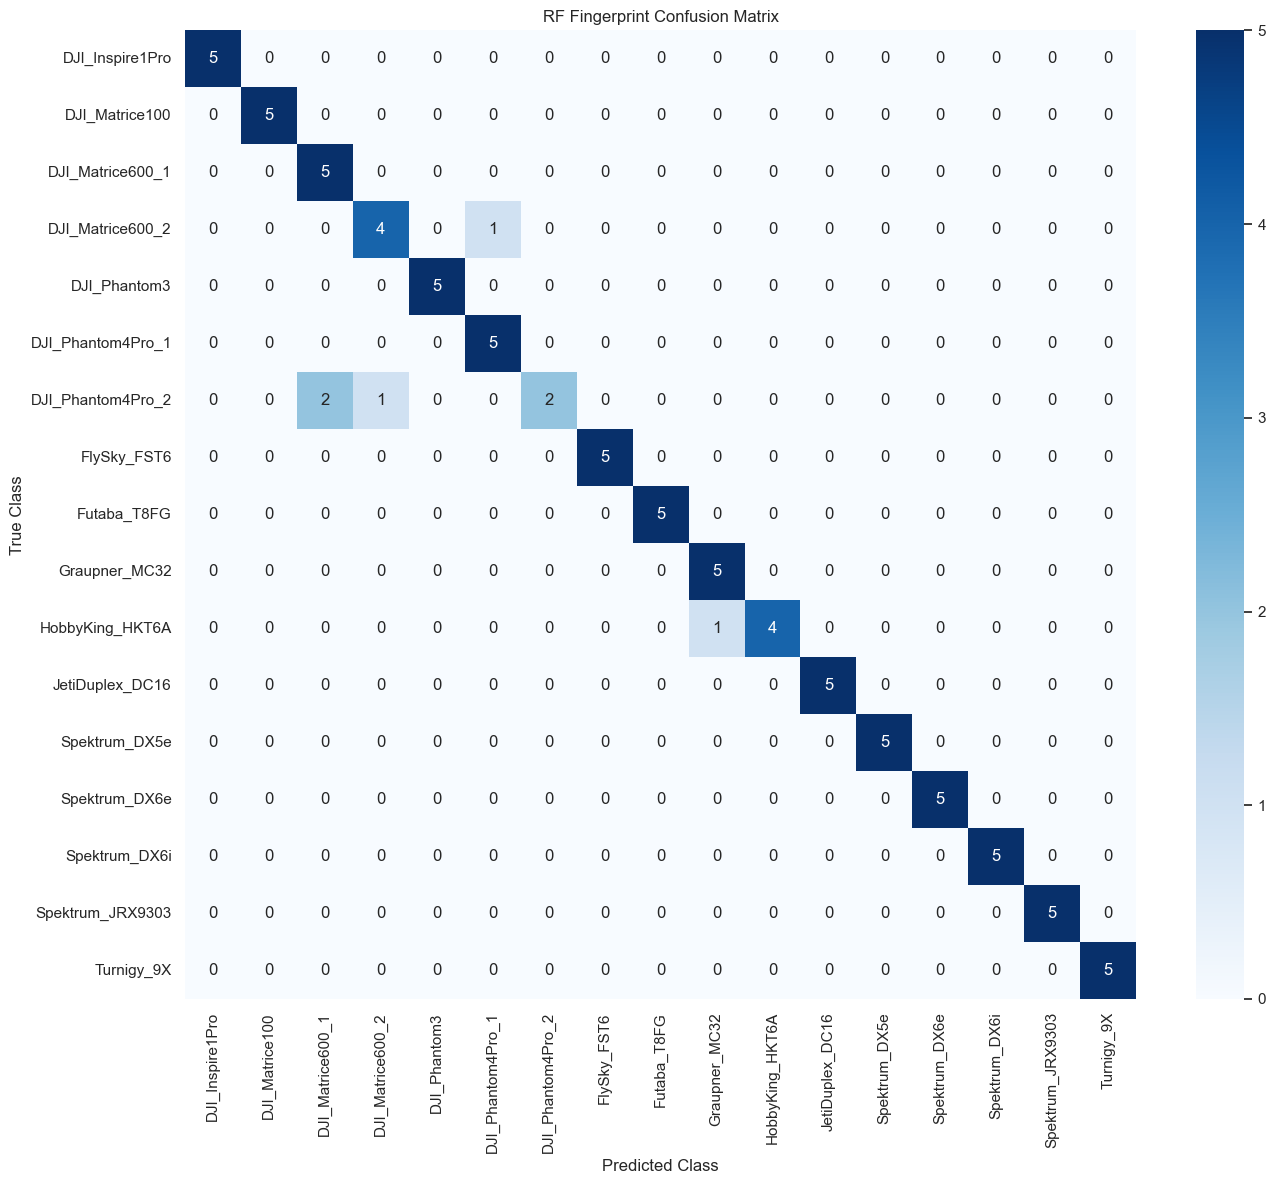

In [57]:
# ============================================================
# Final Test Evaluation + Confusion Matrix
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

# ============================================================
# Evaluate on held-out test set
# ============================================================

test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n===================================")

print("Final Test Performance")

print(f"\nTest Loss     : {test_loss:.4f}")

print(f"Test Accuracy : {test_acc:.4f}")

print("===================================")

# ============================================================
# Predictions
# ============================================================

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

# ============================================================
# Classification Report
# ============================================================

print("\n===================================")

print("Classification Report")

print("===================================\n")

target_names = [
    label_map[i]
    for i in range(len(label_map))
]

print(

    classification_report(
        y_test,
        y_pred,
        target_names=target_names
    )

)

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("RF Fingerprint Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("True Class")

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

3/3 [==============================] - 1s 172ms/step


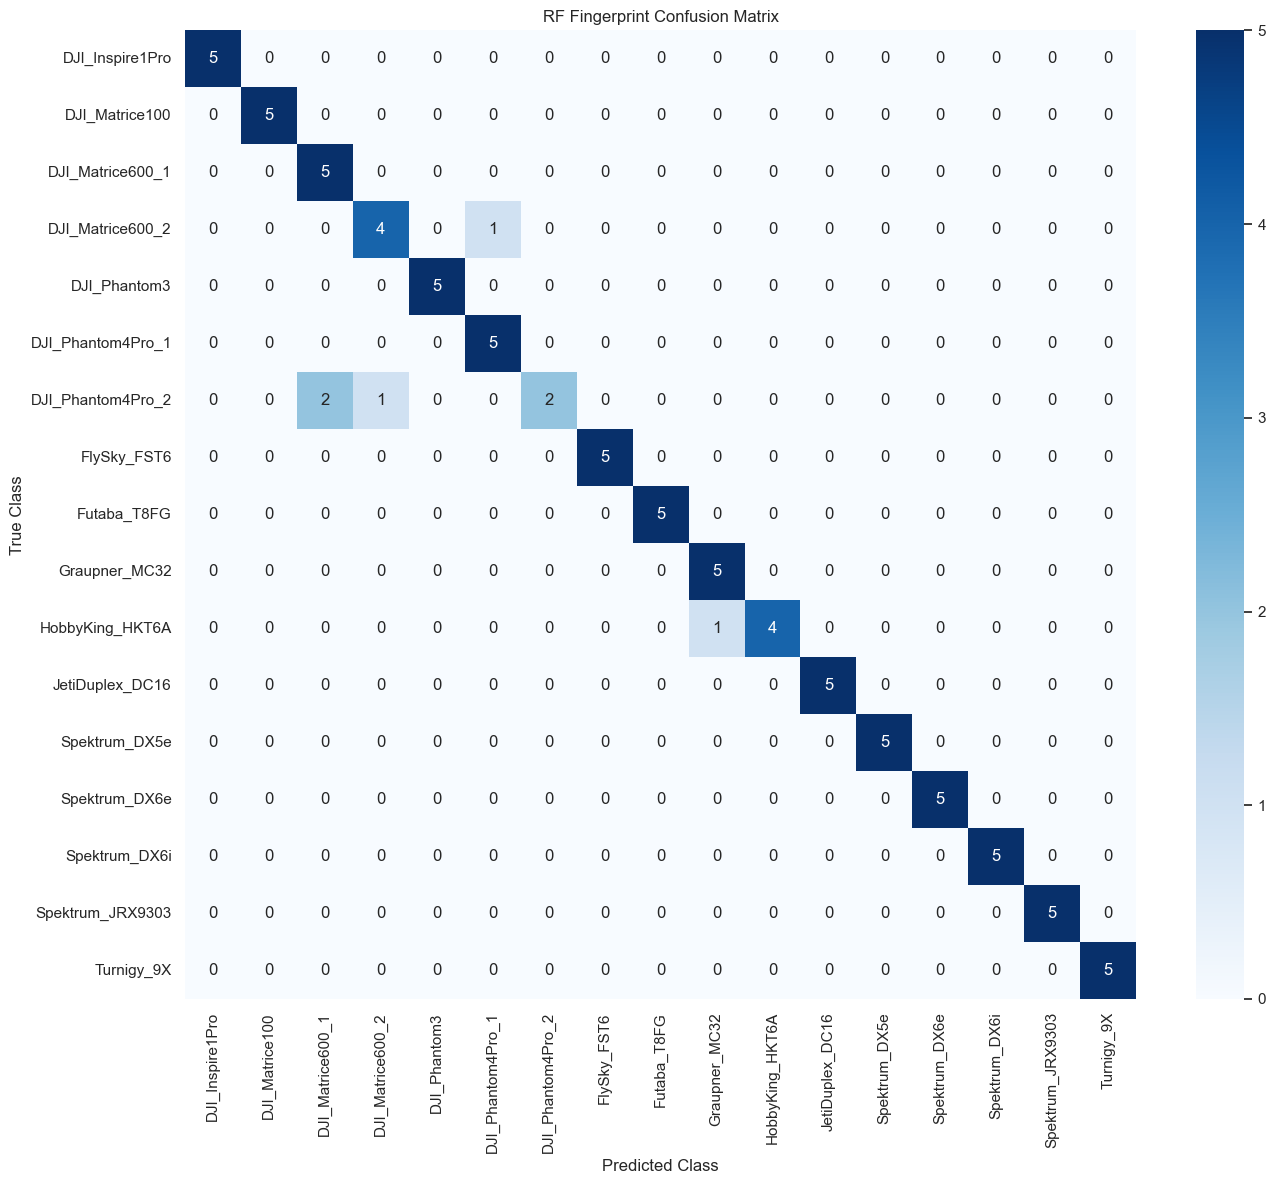


Saved Successfully:

- results.json
- classification_report.csv
- confusion_matrix.csv
- confusion_matrix.png


In [58]:
# ============================================================
# Save Results + Confusion Matrix
# ============================================================

import json
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# ============================================================
# Predictions
# ============================================================

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

# ============================================================
# Evaluate
# ============================================================

test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# ============================================================
# Save metrics
# ============================================================

results = {

    "test_loss": float(test_loss),

    "test_accuracy": float(test_acc)

}

with open("results.json", "w") as f:

    json.dump(results, f, indent=4)

# ============================================================
# Classification report
# ============================================================

target_names = [
    label_map[i]
    for i in range(len(label_map))
]

report = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "classification_report.csv"
)

# ============================================================
# Confusion matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=target_names,
    columns=target_names
)

cm_df.to_csv(
    "confusion_matrix.csv"
)

# ============================================================
# Plot confusion matrix
# ============================================================

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("RF Fingerprint Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("True Class")

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.tight_layout()

# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# Final confirmation
# ============================================================

print("\n===================================")

print("Saved Successfully:")

print("\n- results.json")

print("- classification_report.csv")

print("- confusion_matrix.csv")

print("- confusion_matrix.png")

print("===================================")